# Carga, Transformación y Filtrado de datos

In [9]:
import pandas as pd

# 0. Carga de datasets (Asumiendo nombres estándar del dataset Olist)
df_orders = pd.read_csv('olist_orders_dataset.csv')
df_payments = pd.read_csv('olist_order_payments_dataset.csv')
df_customers = pd.read_csv('olist_customers_dataset.csv')

# 1. Conversión de fechas (Crítico para tu respuesta A)
cols_fecha = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in cols_fecha:
    df_orders[col] = pd.to_datetime(df_orders[col])

# 2. Filtrado PREVIO (Respuesta C: Eficiencia y precisión)
df_orders_delivered = df_orders[df_orders['order_status'] == 'delivered'].copy()

# 3. Merges en cadena (Respuesta B: Conexión de llaves)
# Paso 1: Unir pedidos con pagos por order_id
df_temp = pd.merge(df_orders_delivered, df_payments, on='order_id', how='inner')

# Paso 2: Unir el resultado con clientes por customer_id
df_final = pd.merge(df_temp, df_customers, on='customer_id', how='inner')

# 4. Cálculo de tardanza (Verificación de tu Respuesta A)
df_final['is_late'] = df_final['order_delivered_customer_date'] > df_final['order_estimated_delivery_date']

print("Dataset consolidado exitosamente.")
print(df_final.head())

Dataset consolidado exitosamente.
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp   order_approved_at  \
0    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
1    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
2    delivered      2017-10-02 10:56:33 2017-10-02 11:07:15   
3    delivered      2018-07-24 20:41:37 2018-07-26 03:24:27   
4    delivered      2018-08-08 08:38:49 2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2017-10-0

# 1. Análisis de órdenes por estado geográfico

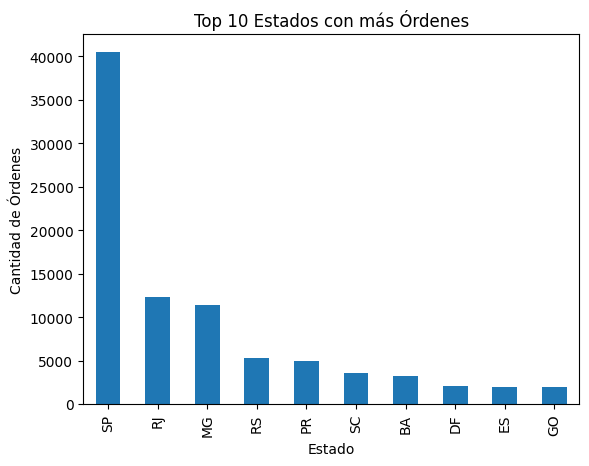

In [11]:
# Contar órdenes únicas por estado
df_ordenes_por_estado = df_final.groupby('customer_state')['order_id'].nunique().sort_values(ascending=False)

# Visualización rápida (barplot)
import matplotlib.pyplot as plt
df_ordenes_por_estado.head(10).plot(kind='bar', title='Top 10 Estados con más Órdenes')
plt.xlabel('Estado')
plt.ylabel('Cantidad de Órdenes')
plt.show()

**Insights Identificados**

Se observa que en Sao Paulo, es donde se concentran la mayor cantidad de ordenes, lo que indica que se deben concentrar los esfuerzos logisticos en este estado, para minimizar los costos asociados de ultima milla.

# 2. Análisis de distribución de metodos de pago

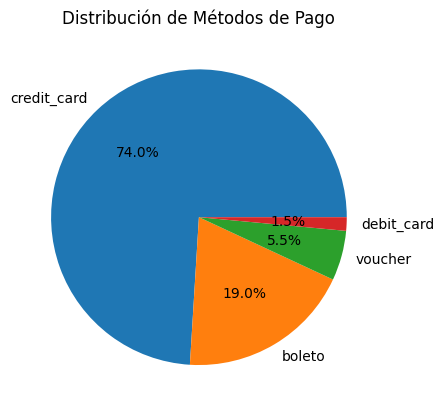

In [12]:
# Distribución de métodos de pago
df_pagos = df_final['payment_type'].value_counts()

# Visualización (pie chart o barplot)
df_pagos.plot(kind='pie', autopct='%1.1f%%', title='Distribución de Métodos de Pago')
plt.ylabel('')
plt.show()

**INSIGHTS IDENTIFICADOS**

Se observa que la tarjeta de credito representa un 74%, frente a un 19% de forma de pago de boleto, por lo que indica que un porcentaje significativo cuenta con servicios financieros formales, información para realizar diseños para posibles promociones o descuentos por pagos anticipados.